# 01 — Data pipeline

Sources ranked by quality: **SEC EDGAR** (official, legal documents) > **Polymarket Gamma** (real money) > **FRED** (official macro) > **yfinance** (market data, Stooq fallback) > **HN/Wikipedia** (attention proxies). Every fetch passes a quality gate. Universe: portfolio (GOOGL), volatility proxy (TSLA), picks-and-shovels (NDAQ, HOOD, VIRT, GS, MS), space sector (RKLB, ASTS, LMT), benchmarks (^GSPC, ^NDX) and the fear gauge (^VIX).

In [1]:
import sys, warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from src.viz import tufte_style, direct_label_lines, corr_heatmap, pnl_distribution, headline, PALETTE, GOOD, BAD, NEUTRAL
tufte_style()

## 1. OHLCV with quality gate

Data-engineering rule: nothing enters the process without passing the checks. **Issues** (NaN, non-positive prices, staleness) block the pipeline; **warnings** (gaps, >50% jumps) are surfaced for human review — extreme moves can be real (ASTS +50% on the AT&T deal, ^VIX Fed-day spikes), so they must be flagged, not auto-dropped.

In [2]:
from src.connectors.market_data import get_universe
from src.config import UNIVERSE  # noqa: F401
prices, reports = get_universe(UNIVERSE, period="2y")
qa = pd.DataFrame(reports).set_index("ticker")
assert qa["issues"].map(len).sum() == 0, f"QUALITY FAIL: {qa[qa.issues.map(len)>0]}"
prices.to_parquet("../data/universe_prices.parquet")
qa

,rows,first,last,missing_bdays,source,issues,warnings
ticker,,,,,,,
GOOGL,501,2024-06-13,2026-06-12,21,yfinance,[],[]
TSLA,501,2024-06-13,2026-06-12,21,yfinance,[],[]
NDAQ,501,2024-06-13,2026-06-12,21,yfinance,[],[]
HOOD,501,2024-06-13,2026-06-12,21,yfinance,[],[]
VIRT,501,2024-06-13,2026-06-12,21,yfinance,[],[]
GS,501,2024-06-13,2026-06-12,21,yfinance,[],[]
MS,501,2024-06-13,2026-06-12,21,yfinance,[],[]
RKLB,501,2024-06-13,2026-06-12,21,yfinance,[],[]
ASTS,501,2024-06-13,2026-06-12,21,yfinance,[],[jump >50% on 2024-08-15 (verify: real move or...


## 2. SEC EDGAR — SpaceX filings (CIK 1181412)

The single most authoritative source: filings are legal acts. From August this is where **Form 4s** appear (insider sales, public by law within 2 business days) — the key dataset for the lockup thesis.

In [3]:
from src.connectors.edgar import recent_filings, form4_watch
fil = pd.DataFrame(recent_filings(limit=15))
print(f"Form 3/4/144 to date: {len(form4_watch())} (expected from August)")
fil

Form 3/4/144 to date: 9 (expected from August)


,form,date,url
0,S-8,2026-06-12,https://www.sec.gov/Archives/edgar/data/118141...
1,424B4,2026-06-12,https://www.sec.gov/Archives/edgar/data/118141...
2,EFFECT,2026-06-11,https://www.sec.gov/Archives/edgar/data/118141...
3,3,2026-06-11,https://www.sec.gov/Archives/edgar/data/118141...
4,3,2026-06-11,https://www.sec.gov/Archives/edgar/data/118141...
5,3,2026-06-11,https://www.sec.gov/Archives/edgar/data/118141...
6,3,2026-06-11,https://www.sec.gov/Archives/edgar/data/118141...
7,3,2026-06-11,https://www.sec.gov/Archives/edgar/data/118141...
8,3,2026-06-11,https://www.sec.gov/Archives/edgar/data/118141...
9,3,2026-06-11,https://www.sec.gov/Archives/edgar/data/118141...


## 3. Polymarket — real-money implied probabilities

In [4]:
from src.connectors.polymarket import search_markets
mkts = search_markets("spacex", limit=10)
pm = pd.DataFrame([{ "market": m["market"], **{f"P({k})": v for k, v in m["outcomes"].items()}, "volume_usd": int(m["volume"])} for m in mkts])
pm

,market,P(Yes),P(No),volume_usd,P(Up),P(Down)
0,Tesla and SpaceX merger officially announced b...,0.0145,0.9855,568664,NaN,NaN
1,Tesla and SpaceX merger officially announced b...,0.3550,0.6450,18867,NaN,NaN
2,SpaceX IPO: Closing Price Up/Down End of First...,NaN,NaN,14100,0.455,0.545
3,Will SpaceX's market cap be less than $1.0T at...,0.0290,0.9710,13077,NaN,NaN
4,Will SpaceX's market cap be between $2.5T and ...,0.1330,0.8670,10513,NaN,NaN
5,Will SpaceX's market cap be between $3.0T and ...,0.0055,0.9945,10302,NaN,NaN
6,Will SpaceX's market cap be between $2.0T and ...,0.3950,0.6050,9097,NaN,NaN
7,Will SpaceX's market cap be between $1.5T and ...,0.3900,0.6100,8900,NaN,NaN
8,Will SpaceX's market cap be between $1.0T and ...,0.0770,0.9230,8858,NaN,NaN
9,Will two SpaceX Starships dock together by Dec...,0.2150,0.7850,5598,NaN,NaN


## 4. Risk-free rate (FRED, ^IRX fallback)

In [5]:
from src.connectors.fred import risk_free_rate
RF = risk_free_rate()
print(f"3M T-bill: {RF:.2%} — the hurdle every strategy must beat, plus friction")

3M T-bill: 3.62% — the hurdle every strategy must beat, plus friction


## 5. Normalized prices — one chart, all the information

Base 100, direct labels (no legend to decode), benchmarks in gray. ^VIX excluded here (different unit), used in notebook 02.

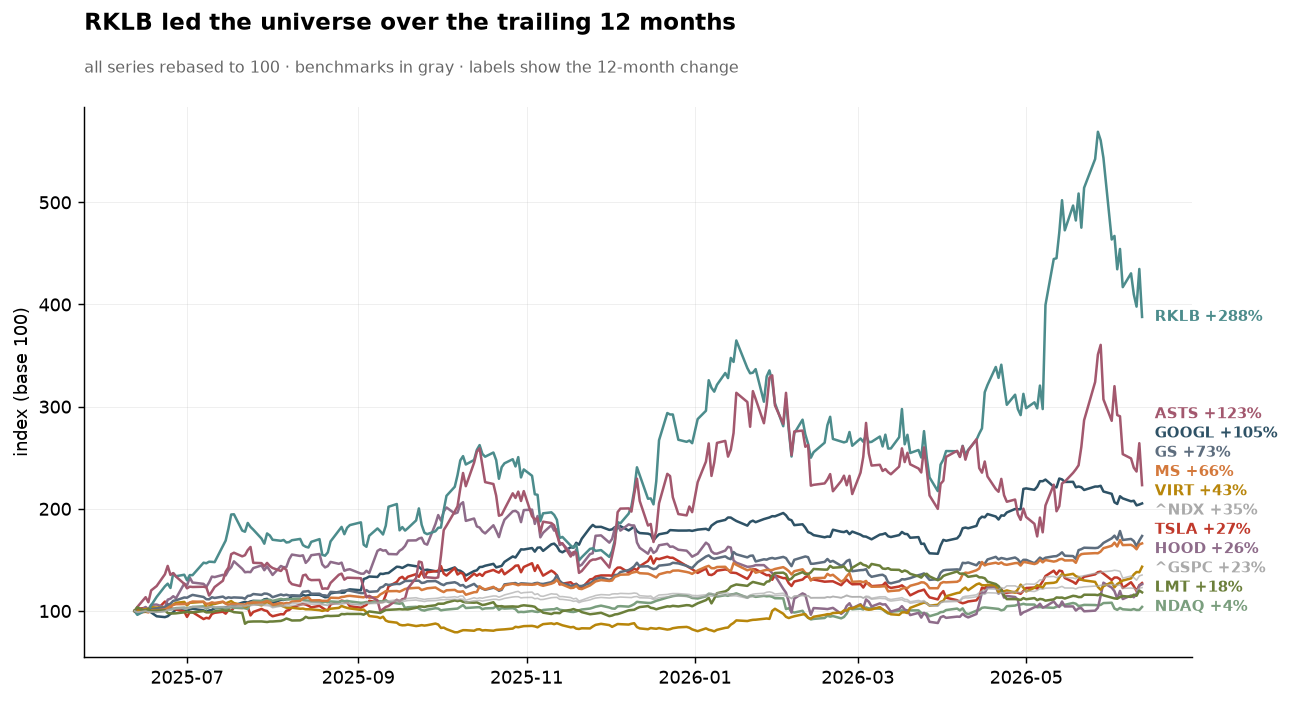

In [6]:
px = prices.drop(columns=["^VIX"]).dropna().tail(252)
norm = 100 * px / px.iloc[0]
fig, ax = plt.subplots(figsize=(11, 5.5))
for c in norm.columns:
    is_bench = c.startswith("^")
    ax.plot(norm.index, norm[c], lw=0.9 if is_bench else 1.4,
            color="#AAAAAA" if is_bench else None, alpha=0.7 if is_bench else 1)
fmt = {c: f"{c} {norm[c].dropna().iloc[-1]-100:+.0f}%" for c in norm.columns}
direct_label_lines(ax, norm, fmt=fmt)
leader = max(norm.columns, key=lambda c: norm[c].dropna().iloc[-1])
headline(ax, f"{leader} led the universe over the trailing 12 months",
         "all series rebased to 100 · benchmarks in gray · labels show the 12-month change")
ax.set_ylabel("index (base 100)")
fig.savefig("../assets/chart_universe.png", bbox_inches="tight")
plt.show()